In [1]:
import seaborn as sns
import torch
import numpy as np
import hashlib
import matplotlib.pyplot as plt 
import os

In [2]:
ckpt_path = '/radraid2/spanchavati/eegfm/lightning_logs_v2/v2_lejepa_pretraining_global_v2mixer_proj/version_2/checkpoints/last.ckpt'
ckpt_hash = hashlib.md5(str(ckpt_path).encode()).hexdigest()[:12]
# ckpt_hash = '0de96d9c9e44'

In [3]:
embedding_to_analyze = f"cache/lejepa_embeddings/abnormal_clinical_{ckpt_hash}_{'297d02079cf4'}_train_v2.npz"

# np.load(embedding_to_analyze)
data = np.load(embedding_to_analyze)

In [4]:
embeddings = data['embeddings']


labels = data['labels']
embeddings_tensor = torch.tensor(embeddings)


In [8]:
labram_embedding_abnormal = '/radraid2/spanchavati/EEGBench/data/embedding_cache/abnormal_clinical_0ff3d32e0c73bc1fc970c816523deea488eef267.pt'
labram_data = torch.load(labram_embedding_abnormal)

#we need to subsample to match the number of samples
labram_embedding = labram_data['features'][:embeddings_tensor.shape[0], :]
labram_labels = labram_data['labels'][:embeddings_tensor.shape[0]]

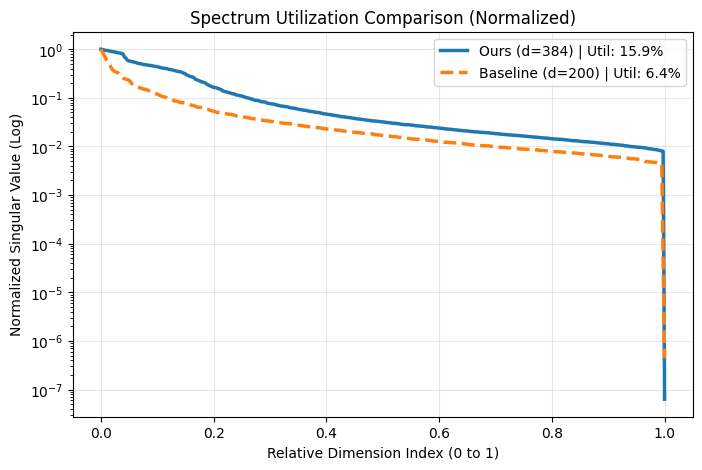

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def get_spectrum_data(z):
    """
    Returns normalized x (0 to 1) and normalized singular values (log scale).
    """
    # 1. Compute SVD
    z = z - z.mean(dim=0, keepdim=True)
    _, S, _ = torch.linalg.svd(z, full_matrices=False)
    S = S.cpu().numpy()
    
    # 2. Compute Metric: Fractional Effective Rank
    # p is the probability distribution of variance
    # probability over variance
    p = (S ** 2) / np.sum(S ** 2)

    entropy = -np.sum(p * np.log(p + 1e-12))
    eff_rank = np.exp(entropy)

    dim = min(z.shape)
    utilization = eff_rank / dim
    
    # 3. Prepare Plot Data
    # Normalize X-axis to [0, 1]
    x_norm = np.linspace(0, 1, len(S))
    
    # Normalize Y-axis (Singular Values) so max is 1.0 (Log scale ready)
    # This removes scale differences due to embedding norm
    s_norm = S / S.max()
    
    return x_norm, s_norm, utilization


z_ours = embeddings_tensor


z_baseline = labram_embedding

# Get Data
x_ours, y_ours, util_ours = get_spectrum_data(z_ours)
x_base, y_base, util_base = get_spectrum_data(z_baseline)

# --- Plotting ---

plt.figure(figsize=(8, 5))

# Plot LeJEPA
plt.plot(x_ours, y_ours, label=f"Ours (d={z_ours.shape[1]}) | Util: {util_ours:.1%}", linewidth=2.5)

# Plot Baseline
plt.plot(x_base, y_base, label=f"Baseline (d={z_baseline.shape[1]}) | Util: {util_base:.1%}", linewidth=2.5, linestyle="--")

plt.yscale('log')
plt.xlabel("Relative Dimension Index (0 to 1)")
plt.ylabel("Normalized Singular Value (Log)")
plt.title("Spectrum Utilization Comparison (Normalized)")
plt.legend()
plt.grid(True, which="major", alpha=0.3)
plt.show()

bci_Left Hand vs Right Hand vs Feet vs Tongue MI_da67e4d4cf8b_2a8c155b93ce_train_v2.npz


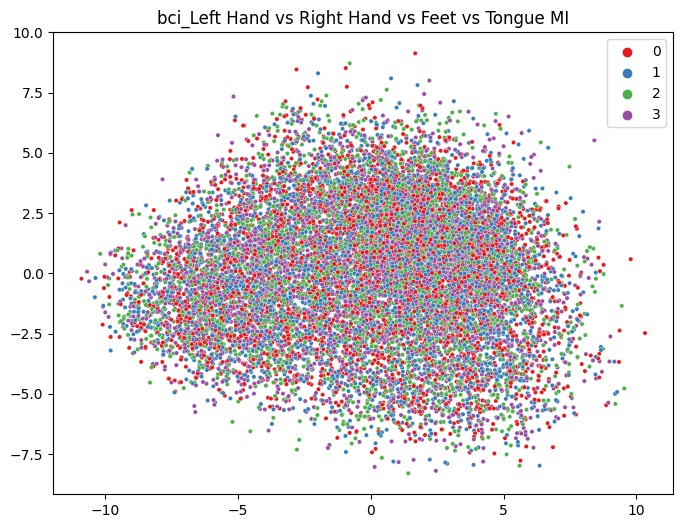

ocd_clinical_da67e4d4cf8b_44d447d52ee3_val_v2.npz


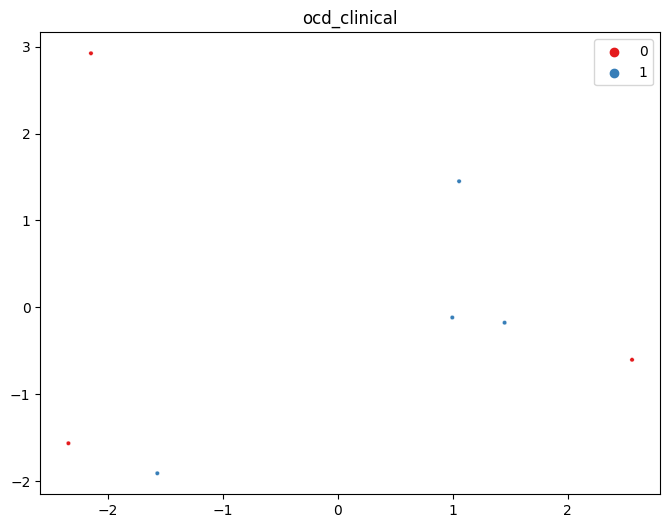

parkinsons_clinical_da67e4d4cf8b_a6ca557769a8_train_v2.npz


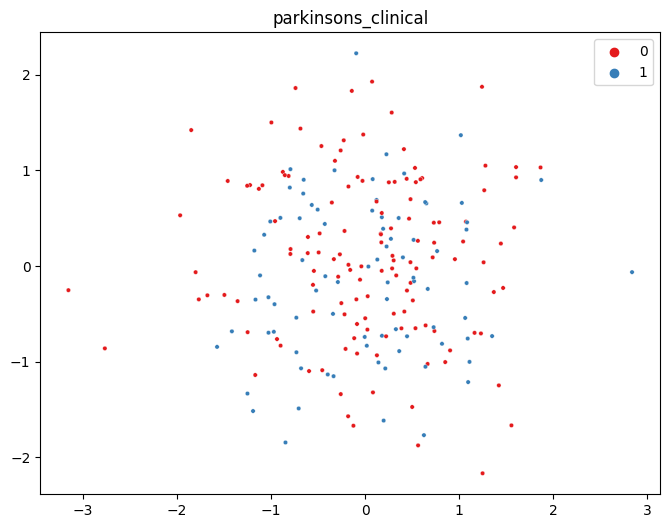

bci_Right Hand vs Feet MI_da67e4d4cf8b_ad6e4553b5f0_val_v2.npz


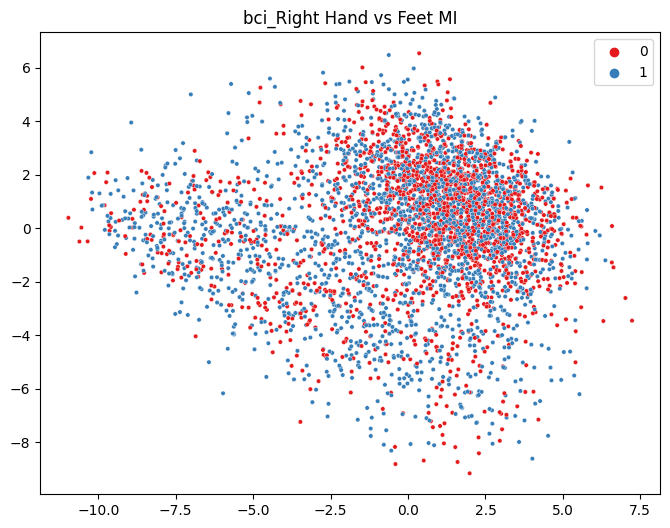

abnormal_clinical_da67e4d4cf8b_297d02079cf4_train_v2.npz


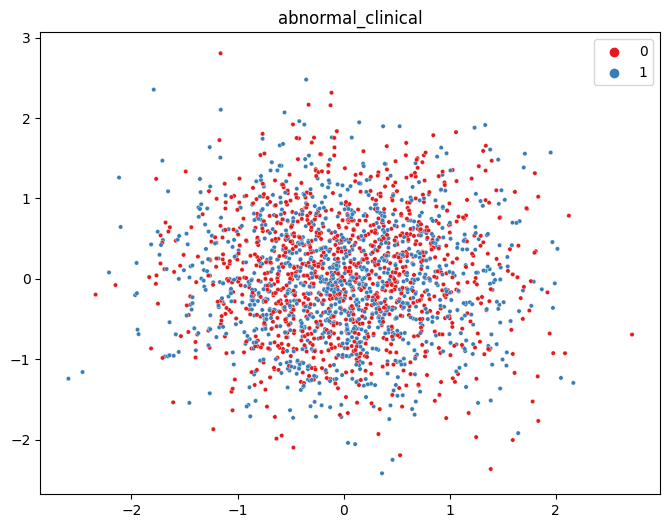

mtbi_clinical_da67e4d4cf8b_d3f1a38ef343_val_v2.npz


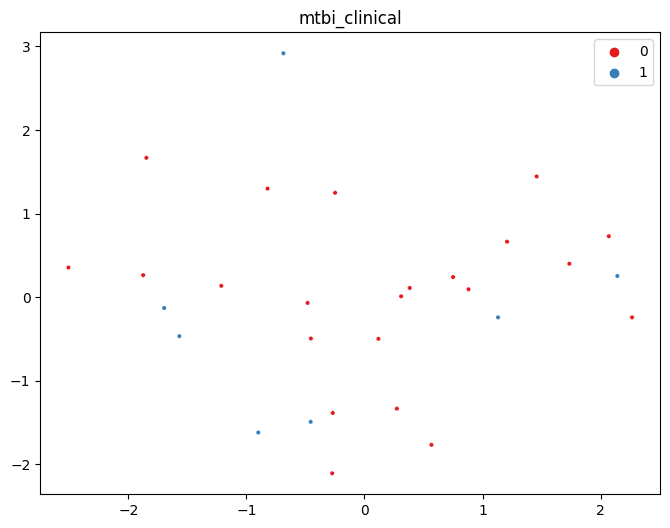

bci_Left Hand vs Right Hand vs Feet vs Tongue MI_da67e4d4cf8b_f658729c5180_val_v2.npz


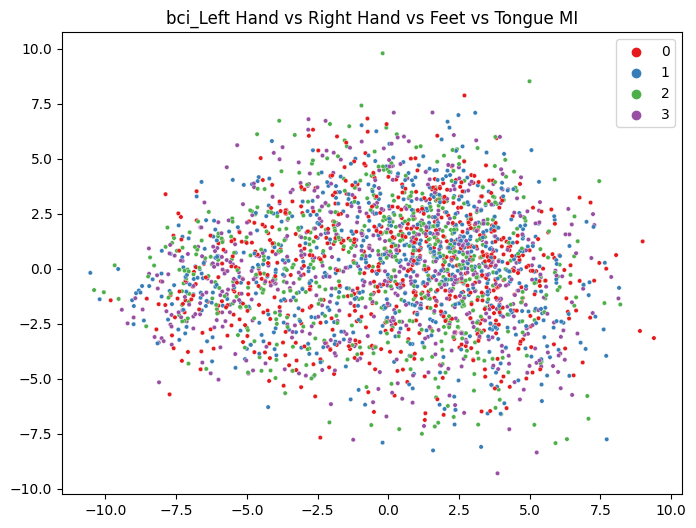

bci_Five Fingers MI_da67e4d4cf8b_b33083f9601a_val_v2.npz


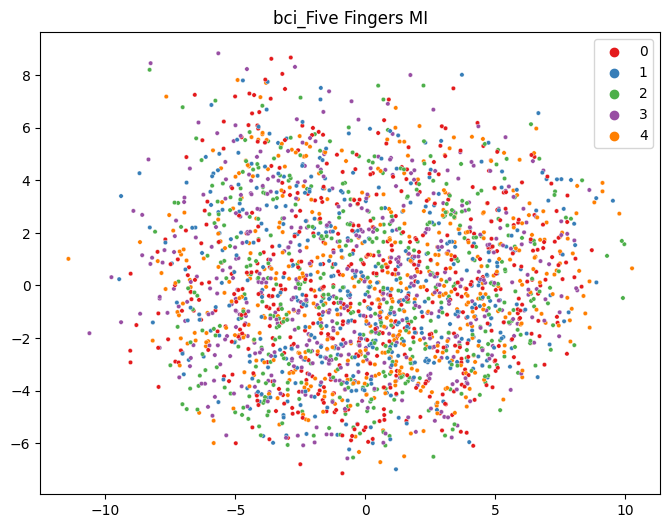

multiclass_artifact_clinical_da67e4d4cf8b_8af820613c70_train_v2.npz
bci_Right Hand vs Feet MI_da67e4d4cf8b_8d9cfc0ad168_train_v2.npz


<Figure size 800x600 with 0 Axes>

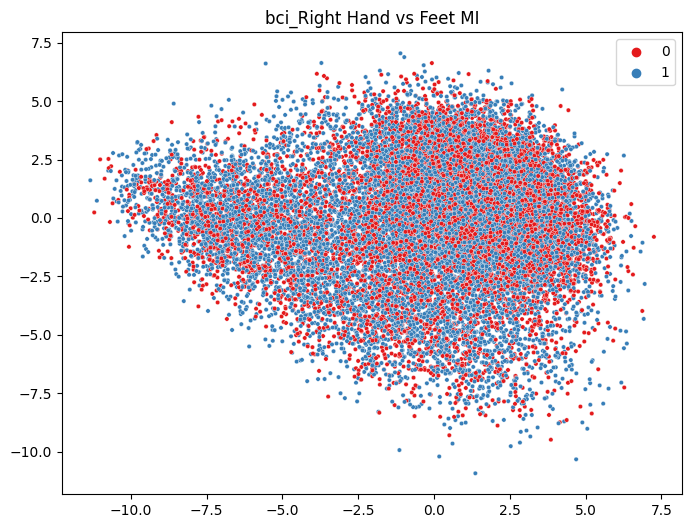

bci_Five Fingers MI_da67e4d4cf8b_cd7336ab77b1_train_v2.npz


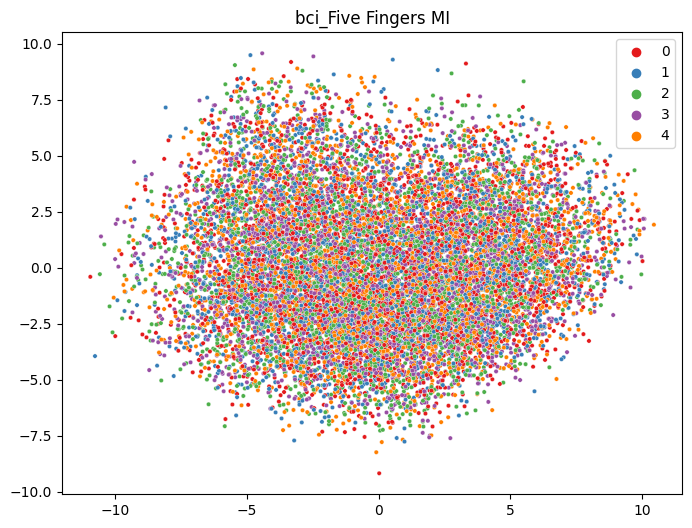

multiclass_artifact_clinical_da67e4d4cf8b_8af820613c70_val_v2.npz
abnormal_clinical_da67e4d4cf8b_297d02079cf4_val_v2.npz


<Figure size 800x600 with 0 Axes>

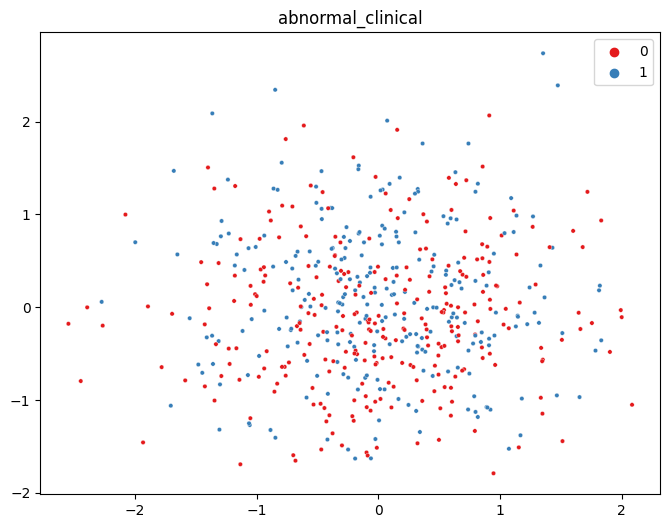

parkinsons_clinical_da67e4d4cf8b_a6ca557769a8_val_v2.npz


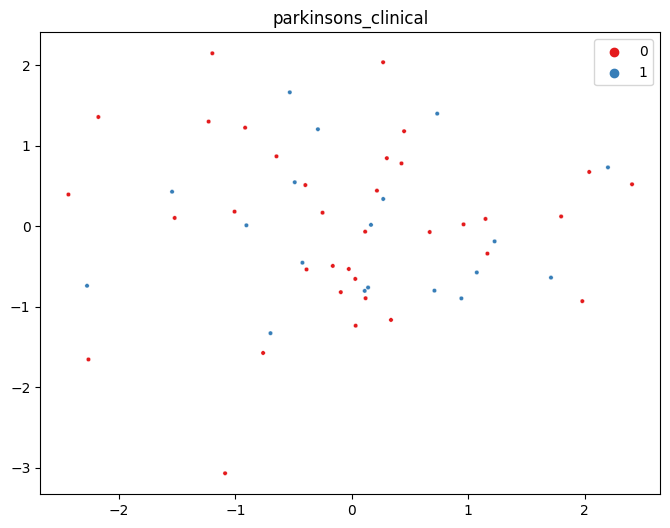

mtbi_clinical_da67e4d4cf8b_d3f1a38ef343_train_v2.npz


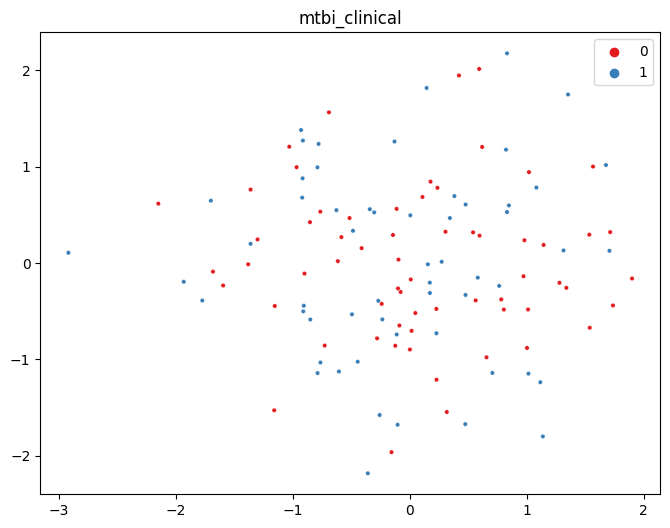

epilepsy_clinical_da67e4d4cf8b_37e74995a1ee_val_v2.npz


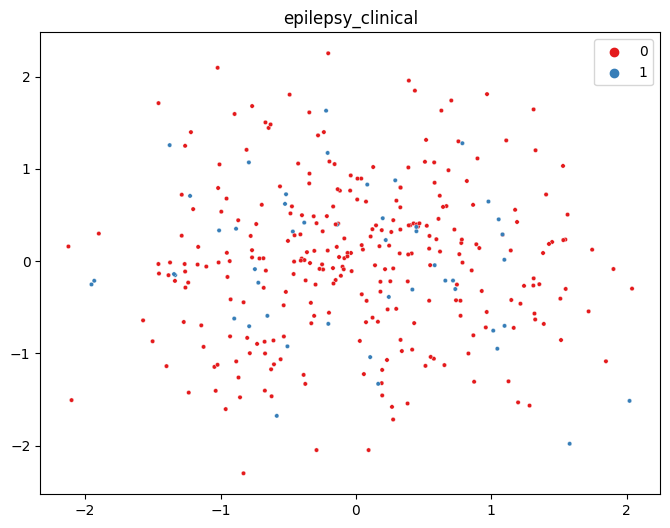

schizophrenia_clinical_da67e4d4cf8b_0901c4f19a6a_val_v2.npz


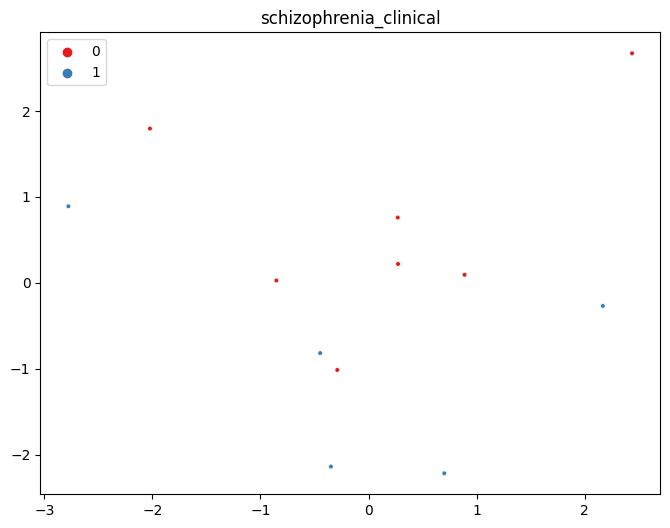

epilepsy_clinical_da67e4d4cf8b_37e74995a1ee_train_v2.npz


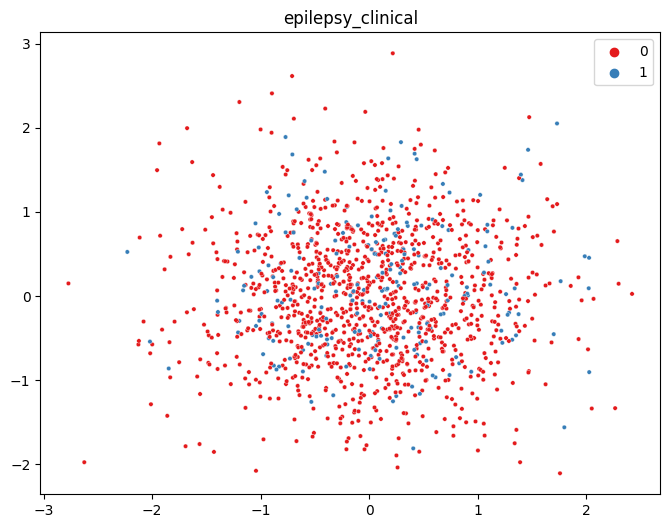

ocd_clinical_da67e4d4cf8b_44d447d52ee3_train_v2.npz


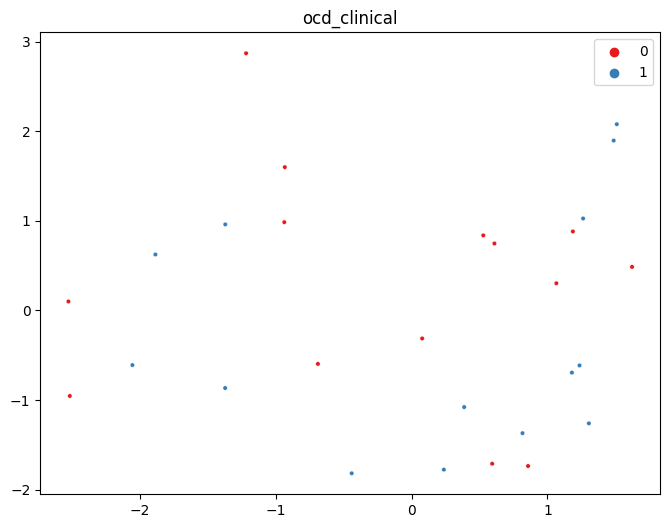

schizophrenia_clinical_da67e4d4cf8b_0901c4f19a6a_train_v2.npz


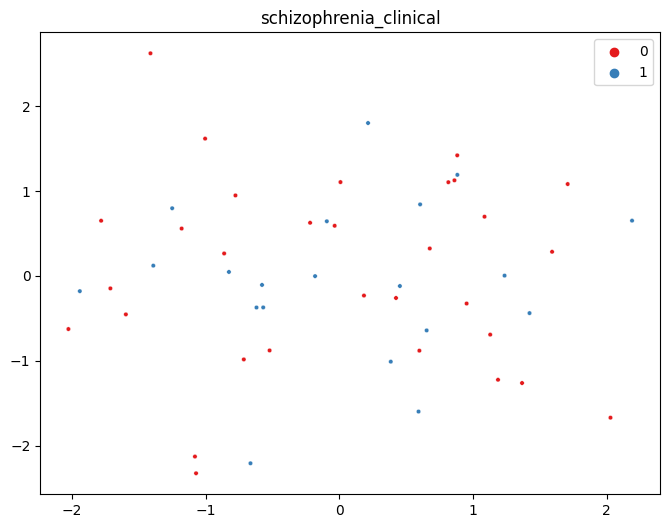

In [19]:
all_embeddings = os.listdir('cache/lejepa_embeddings/')
for emb_file in all_embeddings:
    if ckpt_hash in emb_file:
        print(emb_file)
        data = np.load(os.path.join('cache/lejepa_embeddings/', emb_file))
        embeddings = data['embeddings']
        labels = data['labels']
        decomp = PCA(n_components=2, random_state=42)
        embeddings_2d = decomp.fit_transform(embeddings)

        # if labels.sha

        try:
            plt.figure(figsize=(8,6))
            sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=labels, palette="Set1",s =10)
            title = '_'.join(emb_file.split('_')[:2])
            plt.title(title)
            plt.show() 
        except:
            pass